# Sentinel-1 RTC Backscatter

**Living Earth - Cube in a Box Demo Series**

---

*   **Objective:** Load and visualize Sentinel-1 Radiometrically Terrain Corrected (RTC) radar data.
*   **Products used:** [`sentinel_1_rtc`](http://localhost/explorer/products/sentinel_1_rtc)
*   **Source:** [Planetary Computer Catalog](https://planetarycomputer.microsoft.com/dataset/sentinel-1-rtc)

---

## Background

The Sentinel-1 mission is a constellation of two polar-orbiting satellites, operating day and night performing C-band synthetic aperture radar imaging. The Sentinel-1 Radiometrically Terrain Corrected (RTC) data in this collection is a radiometrically terrain corrected product derived from the Ground Range Detected (GRD) Level-1 products produced by the European Space Agency. The RTC processing is performed by Catalyst.

Radiometric Terrain Correction accounts for terrain variations that affect both the position of a given point on the Earth's surface and the brightness of the radar return, as expressed in radar geometry. Without treatment, the hill-slope modulations of the radiometry threaten to overwhelm weaker thematic land cover-induced backscatter differences. Additionally, comparison of backscatter from multiple satellites, modes, or tracks loses meaning.

## Description

This notebook demonstrates loading RTC backscatter, working with VV/VH polarizations, and exporting results as COGs.

***

In [1]:
import sys
sys.path.insert(1, './utils/')

In [ ]:
# reload module before executing code
%load_ext autoreload
%autoreload 2

import datacube
import psutil
import time
from dask.distributed import Client
from odc.geo.xr import write_cog
from utils.deafrica_plotting import rgb
from utils.le_dc import get_product_bbox
from utils.le_mapping import bbox_to_polygon, display_crosshair, MapHandler
from utils.le_tools import style_output_cells

from planetary_computer import sign_url  # needed to access planetary-computer collection

### Connect to the datacube

In [3]:
dc = datacube.Datacube(app='Sentinel_1_RTC')

In [4]:
# Let's inspect measurements (bands) available.

product = 'sentinel_1_rtc'
dc.list_measurements().loc[product]

,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
vv,vv,float32,1,-32768.0,[VV],NaN
vh,vh,float32,1,-32768.0,[VH],NaN


### Dask dashboard  
In order to optimise usage of your hardware it is recommended to run the next cells to configure Daskerisation and access Dask dashboard, which will allow you to monitor your hardware usage as well as Dask computation progress.  
![](./figures/dask_dashboard.png)

In [5]:
# Get the available cpu(s) number and memory in gigabytes (to properly configure Dask client in follwoing cell)

print(f"Available cpu(s): {psutil.cpu_count()}")

available_memory = psutil.virtual_memory().available
available_memory_gb = available_memory / (1024 ** 3)
print(f"Available memory: {available_memory_gb:.2f} GB")

Available cpu(s): 4
Available memory: 19.58 GB


In [6]:
try:
    client.dashboard_link
except:
    client = Client(n_workers=4, memory_limit='4GB')  # memory_limit PER WORKER !
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /jupyter/user/bruno/proxy/8787/status,
Dashboard: /jupyter/user/bruno/proxy/8787/status,Workers: 4
Total threads: 4,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38721,Workers: 0
Dashboard: /jupyter/user/bruno/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43281,Total threads: 1
Dashboard: /jupyter/user/bruno/proxy/38973/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:40371,


## Load data

Now that we know what measurements are available for the product, we can load data from the datacube using `dc.load`.

In the example below, we will loadthe two measurements (bands) available (`vv` and `vh`). By specifying `output_crs='EPSG:6933'` and `resolution=10`, we request that datacube reproject our data to the African Albers coordinate reference system (CRS), with 10 x 10 m pixels. Finally, `group_by='solar_day'` ensures that overlapping images taken within seconds of each other as the satellite passes over are combined into a single time step in the data.

In [7]:
# Check if default bbox is contained within the datacube
# and allow user to draw bbox if not.

# configure a default bounding box and visualize it
lat, lon = 30.37106,32.27729
buffer = 0.05
default_bbox = (lon - buffer, lat - buffer, lon + buffer, lat + buffer)

product_bbox = get_product_bbox(dc, product, split_size=10, stability_threshold=4)

is_contained =(default_bbox[0] >= product_bbox[0] and
               default_bbox[1] >= product_bbox[1] and
               default_bbox[2] <= product_bbox[2] and
               default_bbox[3] <= product_bbox[3]
              )

In [8]:
# Create an instance of MapHandler
map_handler = MapHandler()
m, drc = map_handler.create_map(vect=[bbox_to_polygon(default_bbox), bbox_to_polygon(product_bbox)],
                               draw_rect=True)
display(m)

# append crosshair
time.sleep(2)  # make sure m is fully displayed
display_crosshair()

Map(center=[24.95819325, 30.002350100000005], controls=(AttributionControl(options=['position', 'prefix'], pos…

<IPython.core.display.Javascript object>

In [9]:
# Warn in case of full AoI
aoi_poly = map_handler.aoi_tupple

if aoi_poly is None:
    aoi_poly = tuple(default_bbox)
    if not is_contained:
        style_output_cells('salmon', border_color='red', border_width='2px')
        print('The area of interest polygon is located outside of the product extent.' + \
              '\nPlease draw a new area of interest in the previous cell.')
    else:
        # When is_contained is True and no polygon drawn - this is actually OK!
        style_output_cells()
        print('Default area of interest is contained within the product extent, but you can still draw another one in the previous cell.')
else:
    # A polygon was drawn
    style_output_cells()
    print('Custom area of interest polygon has been created.')

Default area of interest is contained within the product extent, but you can still draw another one in the previous cell.


In [10]:
query = {
    'time': ('2021-12-01', '2021-12-10'),
    'x': (aoi_poly[0], aoi_poly[2]),
    'y': (aoi_poly[1], aoi_poly[3]),
    'output_crs': 'epsg:6933',
    'resolution':10,
}

In [11]:
#load data
lazy_ds = dc.load(product=product,
             dask_chunks={},
             **query)

print(lazy_ds)

<xarray.Dataset> Size: 34MB
Dimensions:      (time: 4, y: 1105, x: 965)
Coordinates:
  * time         (time) datetime64[ns] 32B 2021-12-01T15:56:18.149070 ... 202...
  * y            (y) float64 9kB 3.705e+06 3.705e+06 ... 3.694e+06 3.694e+06
  * x            (x) float64 8kB 3.109e+06 3.11e+06 ... 3.119e+06 3.119e+06
    spatial_ref  int32 4B 6933
Data variables:
    vv           (time, y, x) float32 17MB dask.array<chunksize=(1, 1105, 965), meta=np.ndarray>
    vh           (time, y, x) float32 17MB dask.array<chunksize=(1, 1105, 965), meta=np.ndarray>
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref


The returned dataset contains all of the bands available for Sentinel-2. These bands are named using the datasets native band-names.  We can also specify which bands to return using band-name `aliases`, such as `red` or `nir`. We do this using the parameter `measurements`.

In [12]:
bands = ['vv', 'vh']

lazy_ds = dc.load(product=product,
                  measurements=bands,
                  dask_chunks={},
                  patch_url=sign_url,
                  **query)

print(lazy_ds)

<xarray.Dataset> Size: 34MB
Dimensions:      (time: 4, y: 1105, x: 965)
Coordinates:
  * time         (time) datetime64[ns] 32B 2021-12-01T15:56:18.149070 ... 202...
  * y            (y) float64 9kB 3.705e+06 3.705e+06 ... 3.694e+06 3.694e+06
  * x            (x) float64 8kB 3.109e+06 3.11e+06 ... 3.119e+06 3.119e+06
    spatial_ref  int32 4B 6933
Data variables:
    vv           (time, y, x) float32 17MB dask.array<chunksize=(1, 1105, 965), meta=np.ndarray>
    vh           (time, y, x) float32 17MB dask.array<chunksize=(1, 1105, 965), meta=np.ndarray>
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref


In [13]:
%%time

# customized chunking is less buggy when performed after loading !!!
lazy_ds = lazy_ds.chunk({"x": 512, "y": 512, "time": 1})

ds = lazy_ds.compute()
print(ds)

<xarray.Dataset> Size: 34MB
Dimensions:      (time: 4, y: 1105, x: 965)
Coordinates:
  * time         (time) datetime64[ns] 32B 2021-12-01T15:56:18.149070 ... 202...
  * y            (y) float64 9kB 3.705e+06 3.705e+06 ... 3.694e+06 3.694e+06
  * x            (x) float64 8kB 3.109e+06 3.11e+06 ... 3.119e+06 3.119e+06
    spatial_ref  int32 4B 6933
Data variables:
    vv           (time, y, x) float32 17MB 0.08034 0.04048 ... 0.04624 0.04251
    vh           (time, y, x) float32 17MB 0.009413 0.007938 ... 0.006886
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref
CPU times: user 429 ms, sys: 120 ms, total: 549 ms
Wall time: 4.95 s


In [14]:
# set nodata to nan

ds = ds.where(ds != -32768.0)

In [15]:
ds['vv-vh'] = ds['vv'] - ds['vh']
print(ds)

<xarray.Dataset> Size: 51MB
Dimensions:      (time: 4, y: 1105, x: 965)
Coordinates:
  * time         (time) datetime64[ns] 32B 2021-12-01T15:56:18.149070 ... 202...
  * y            (y) float64 9kB 3.705e+06 3.705e+06 ... 3.694e+06 3.694e+06
  * x            (x) float64 8kB 3.109e+06 3.11e+06 ... 3.119e+06 3.119e+06
    spatial_ref  int32 4B 6933
Data variables:
    vv           (time, y, x) float32 17MB 0.08034 0.04048 ... 0.04624 0.04251
    vh           (time, y, x) float32 17MB 0.009413 0.007938 ... 0.006886
    vv-vh        (time, y, x) float32 17MB 0.07093 0.03255 ... 0.04285 0.03562
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref


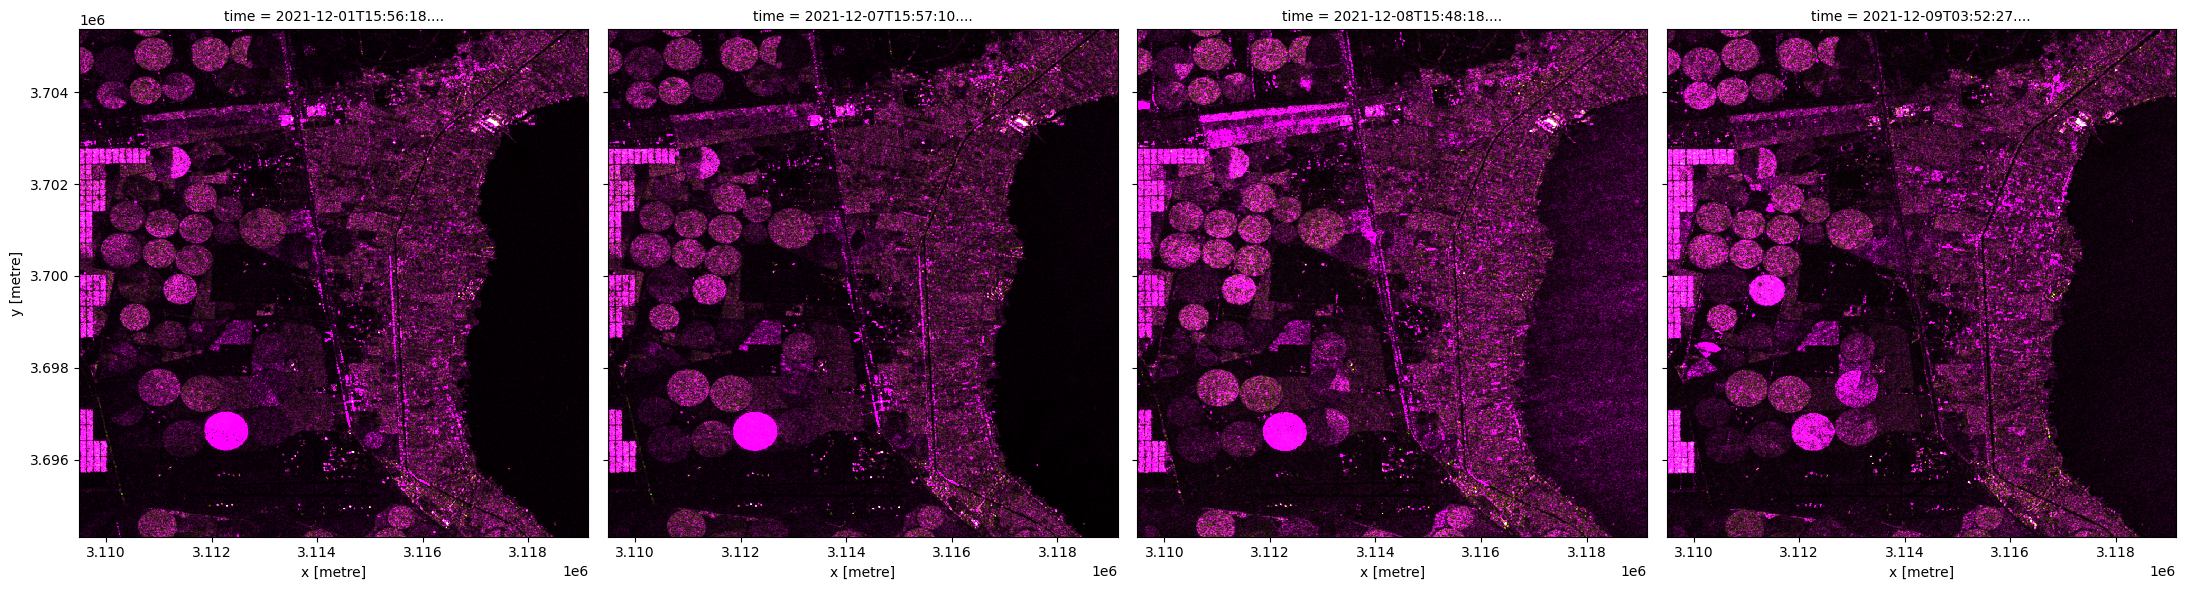

In [16]:
# Plot a composite of all scenes

rgb(ds, bands= ['vv', 'vh', 'vv-vh'], col="time", col_wrap=4, robust=True)

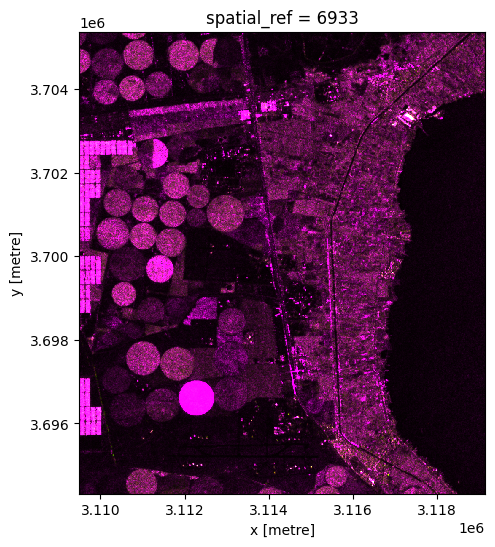

In [17]:
rgb(ds.median(dim='time'), bands= ['vv', 'vh', 'vv-vh'], robust=True)

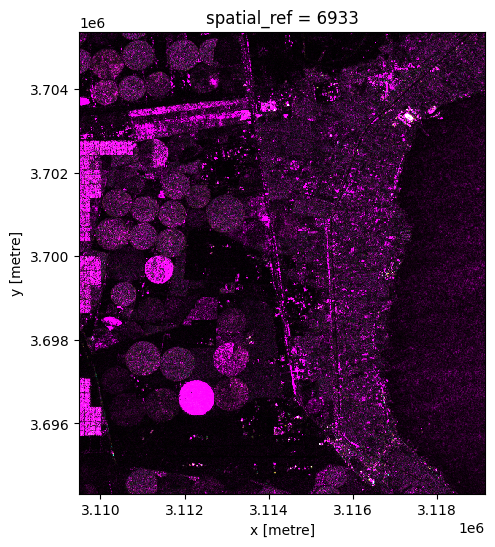

In [18]:
rgb(ds.std(dim='time'), bands= ['vv', 'vh', 'vv-vh'], robust=True)

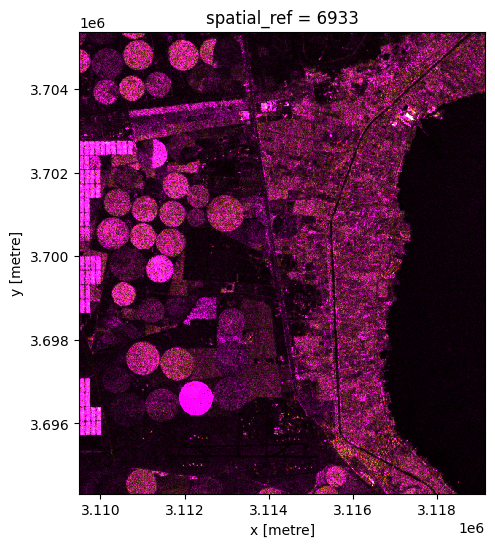

In [19]:
rgb(ds.min(dim='time'), bands= ['vv', 'vh', 'vv-vh'], robust=True)

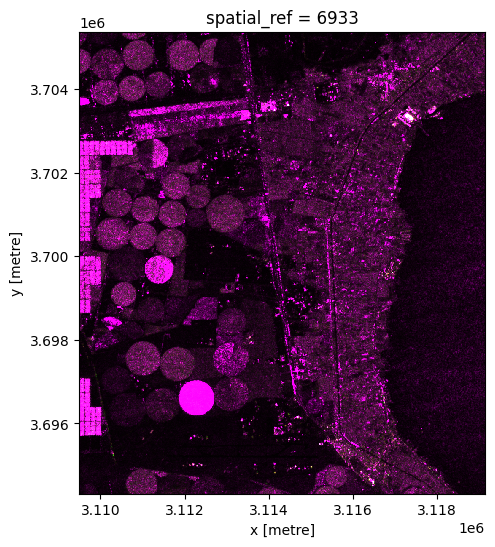

In [20]:
rgb(ds.max(dim='time'), bands= ['vv', 'vh', 'vv-vh'], robust=True)

In [21]:
from odc.geo.xr import write_cog
write_cog(ds.isel(time=0).to_array(), 'ds_0.tif', overwrite=True)

PosixPath('ds_0.tif')

In [22]:
write_cog(ds.std(dim='time').to_array(), 'ds_std.tif', overwrite=True)

PosixPath('ds_std.tif')

In [23]:
for idx in range(len(ds.time)):
    write_cog(ds['vv-vh'].isel(time=idx), f"ds_vh-vh_{idx}.tif", overwrite=True)

***

## Additional information

**License:** The code in this notebook is slighly modified from https://github.com/digitalearthafrica/deafrica-sandbox-notebooks and licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0).

**Compatible datacube version:**

In [24]:
print(datacube.__version__)

1.9.13


**Last tested:**

In [25]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2026-02-24'

In [26]:
!pip freeze

affine==2.4.0
ai-edge-litert==2.1.2
aiobotocore==3.1.1
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aioitertools==0.13.0
aiosignal==1.4.0
alembic==1.18.3
annotated-types==0.7.0
antimeridian==0.4.4
anyio==4.12.1
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.4.0
asttokens==3.0.1
async-lru==2.1.0
attrs==25.4.0
babel==2.18.0
backports.strenum==1.2.8
beautifulsoup4==4.14.3
bleach==6.3.0
bokeh==3.8.2
boltons==25.0.0
boto3==1.42.30
botocore==1.42.30
branca==0.8.2
cachetools==7.0.0
cattrs==25.3.0
certifi==2026.1.4
certipy==0.2.2
cffi==2.0.0
cftime==1.6.5
charset-normalizer==3.4.4
ciso8601==2.3.3
click==8.1.8
click-plugins==1.1.1.2
cligj==0.7.2
cloudpickle==3.1.2
comm==0.2.3
contourpy==1.3.3
cryptography==46.0.4
cycler==0.12.1
dask==2025.7.0
dask-image==2025.11.0
dask_labextension==7.0.0
datacube==1.9.13
datadog==0.52.1
debugpy==1.8.20
decorator==5.2.1
defusedxml==0.7.1
deprecat==2.1.3
distributed==2025.7.0
eodatasets3==1.9.3
executing==2.2.1
fastjsonschema==2.21.2
fiona==1.10.1
flatbuff